<a href="https://colab.research.google.com/github/aditi-0926/customer_segments/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading

In [1]:
import pandas as pd

df = pd.read_csv('ifood_df.csv')
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


Data Cleaning

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [3]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [4]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [5]:
df.duplicated().sum()

np.int64(184)

In [6]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


Feature Engineering

In [7]:
#total spending
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

In [8]:
#total purchases
df['Total_Purchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

Visualizations

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


Income Distribution

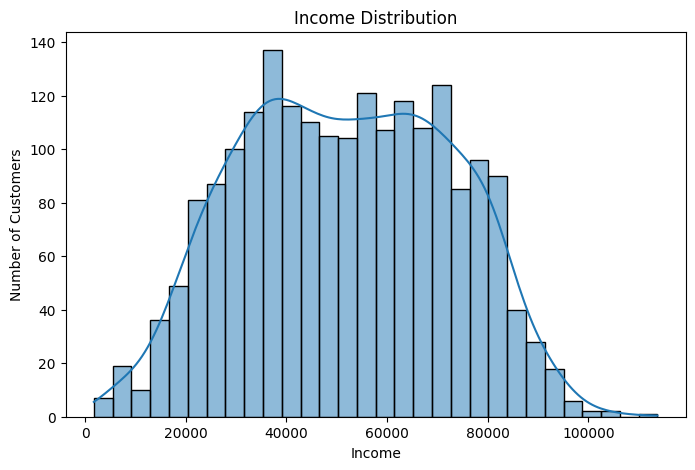

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde=True)

plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Number of Customers')

plt.show()

Spending Distribution:

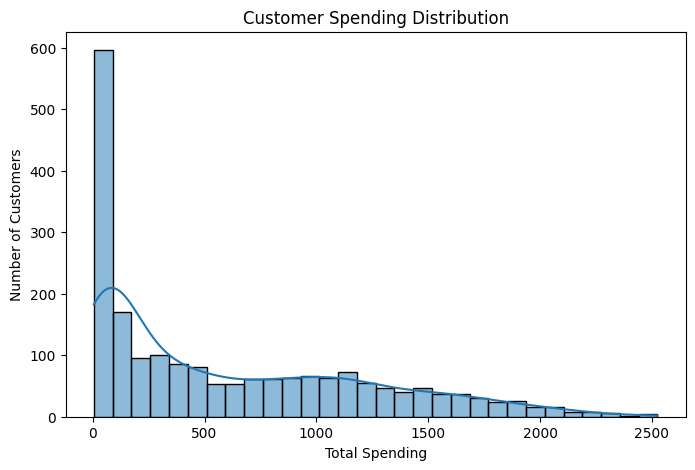

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Spending'],
    bins=30,
    kde=True
)

plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

Purchase Distribution

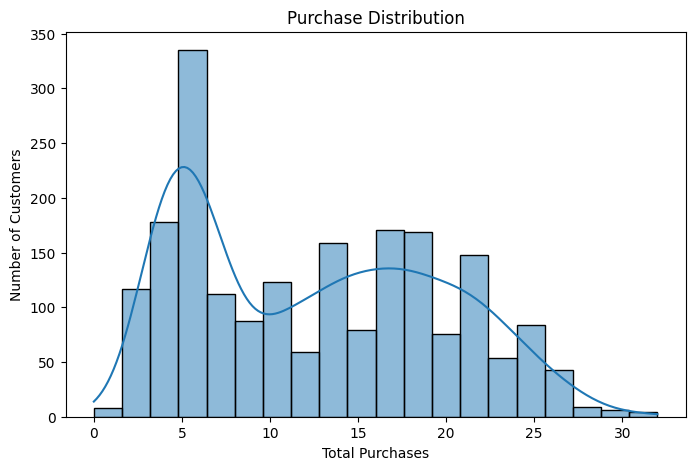

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Purchases'],
    bins=20,
    kde=True
)

plt.title('Purchase Distribution')
plt.xlabel('Total Purchases')
plt.ylabel('Number of Customers')

plt.show()

Correlation Heatmap

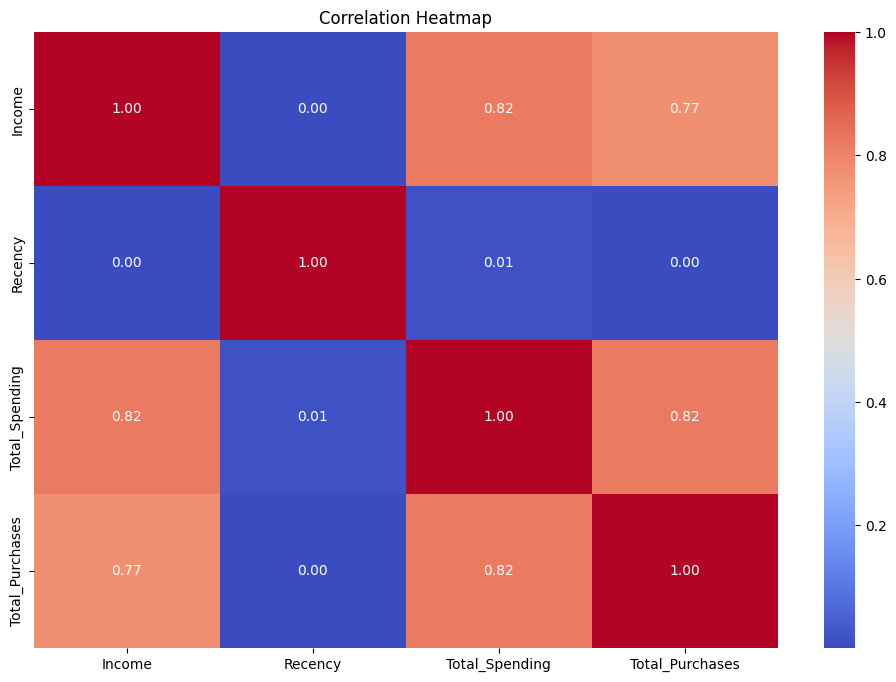

In [13]:
plt.figure(figsize=(12,8))

corr = df[
    [
        'Income',
        'Recency',
        'Total_Spending',
        'Total_Purchases'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Income vs Spending Scatter Plot

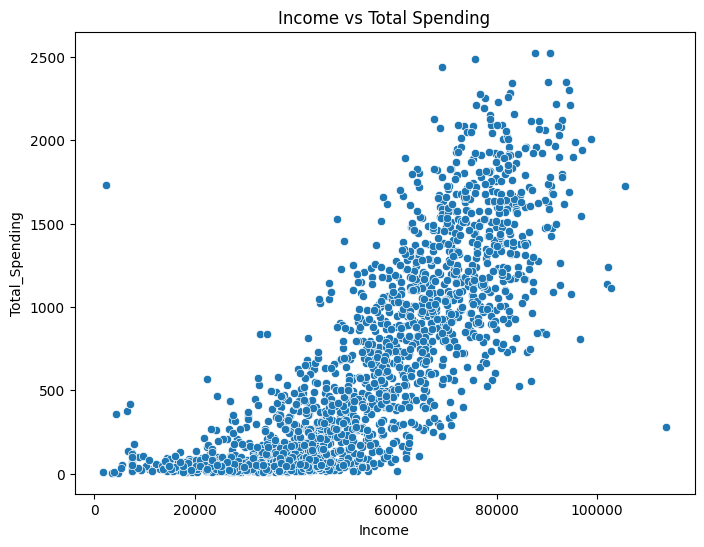

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending'
)

plt.title('Income vs Total Spending')

plt.show()

Feature Selection

In [15]:
features = [
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Recency'
]

X = df[features]

In [16]:
X.head()

,Income,Total_Spending,Total_Purchases,Recency
0,58138.0,1617,22,58
1,46344.0,27,4,38
2,71613.0,776,20,26
3,26646.0,53,6,26
4,58293.0,422,14,94


Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
print(X_scaled[:5])

[[ 0.3115108   1.67587182  1.31725383  0.31506791]
 [-0.2580297  -0.96424046 -1.19646698 -0.37592748]
 [ 0.96222798  0.27943507  1.03795151 -0.79052471]
 [-1.2092599  -0.92106881 -0.91716467 -0.79052471]
 [ 0.31899586 -0.30836351  0.20004458  1.55885961]]


Elbow Method

In [19]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

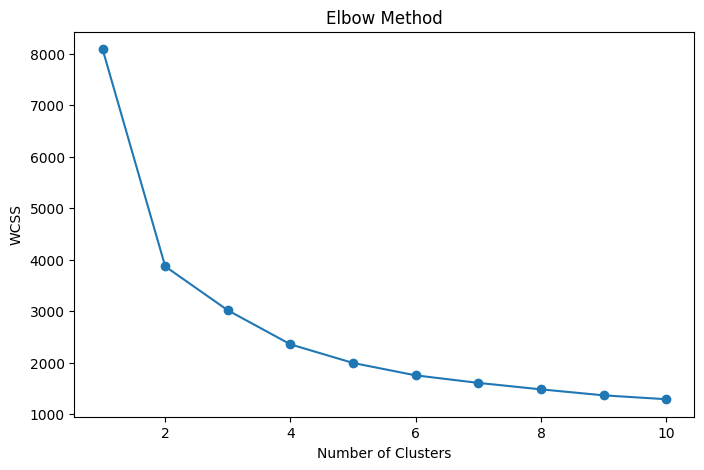

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

Apply K-Means

In [21]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
df[['Income','Total_Spending','Cluster']].head()

,Income,Total_Spending,Cluster
0,58138.0,1617,2
1,46344.0,27,3
2,71613.0,776,1
3,26646.0,53,3
4,58293.0,422,2


Visualize Customer Segments

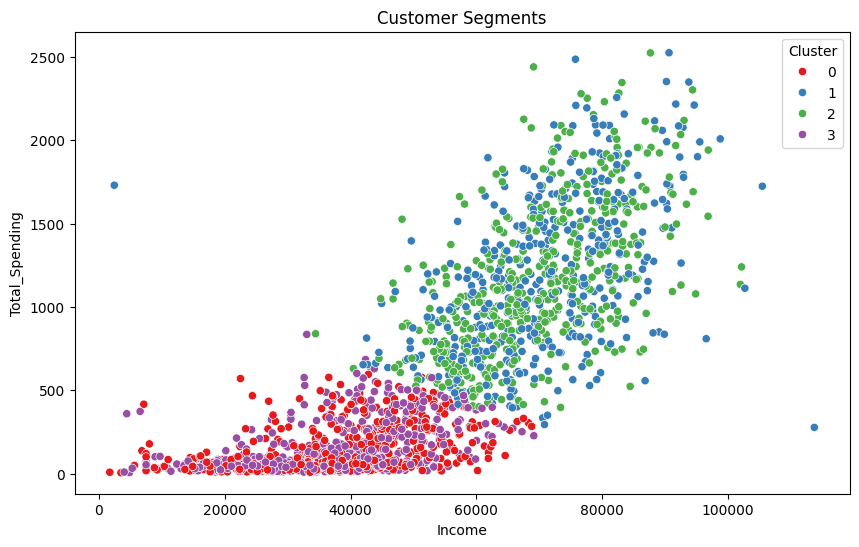

In [23]:
#Income vs Spending
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()

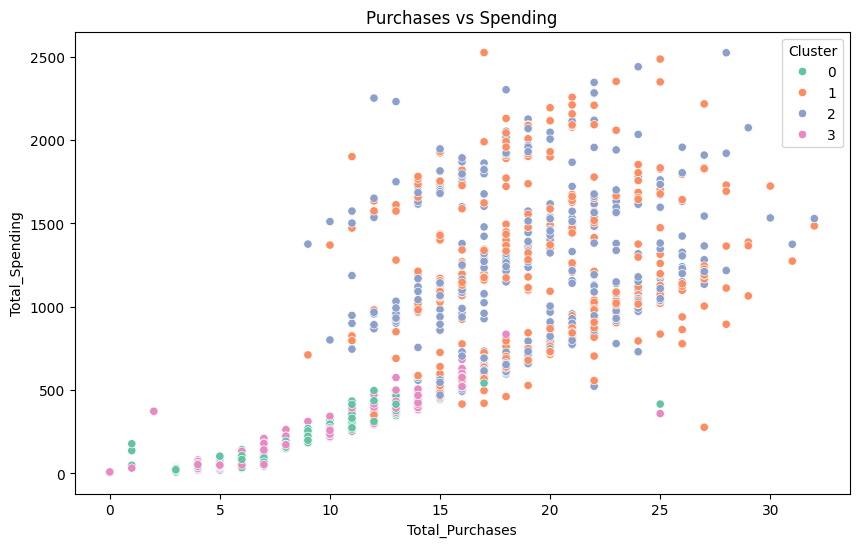

In [24]:
#Spending vs Purchases
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Total_Purchases',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2'
)

plt.title('Purchases vs Spending')
plt.show()

Cluster Analysis

In [25]:
cluster_summary = df.groupby('Cluster')[
    ['Income',
     'Total_Spending',
     'Total_Purchases',
     'Recency']
].mean()

cluster_summary

,Income,Total_Spending,Total_Purchases,Recency
Cluster,,,,
0,36564.302120,140.053004,6.939929,72.613074
1,70674.236239,1175.818807,19.490826,23.284404
2,69418.493776,1153.639004,19.004149,73.439834
3,36295.854749,149.353818,7.100559,22.605214
